In [6]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

input_path  = "../data/college_scorecard_clean.csv"

Loading cleaned dataset

In [16]:
df= pd.read_csv(input_path)
df

,unitid,name,state,region,city,control,pred_deg,ic_level,hbcu,hsi,...,pct_pell,enrollment,med_fam_inc,pct_first_gen,md_earn_6yr,md_earn_10yr,completion_rate,retention_rate,sat_composite,tuition
0,100654,Alabama A & M University,AL,5,Normal,public,3,1,1.0,0.0,...,0.6298,6124.0,23553.0,0.365828,27851.0,40628.0,0.2403,0.6989,938.0,18634.0
1,100663,University of Alabama at Birmingham,AL,5,Birmingham,public,3,1,0.0,0.0,...,0.3402,11635.0,34489.0,0.341224,46572.0,54501.0,0.6423,0.8009,1258.0,22562.0
2,100690,Amridge University,AL,5,Montgomery,private_np,3,1,0.0,0.0,...,0.7655,241.0,15033.5,0.512500,30377.0,37621.0,1.0000,NaN,NaN,7590.0
3,100706,University of Alabama in Huntsville,AL,5,Huntsville,public,3,1,0.0,0.0,...,0.2464,6591.0,44787.0,0.310132,55610.0,61767.0,0.6429,0.8425,1319.0,26408.0
4,100724,Alabama State University,AL,5,Montgomery,public,3,1,1.0,0.0,...,0.7134,3477.0,22080.5,0.343434,27453.0,34502.0,0.3034,0.6975,976.0,19576.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2465,45920402,Unitek College - Sacramento,CA,8,Sacramento,private_fp,0,1,NaN,NaN,...,NaN,NaN,27729.0,0.440580,62043.0,79550.0,NaN,NaN,NaN,NaN
2466,45920403,Unitek College - Concord,CA,8,Concord,private_fp,0,1,NaN,NaN,...,NaN,NaN,27729.0,0.440580,62043.0,79550.0,NaN,NaN,NaN,NaN
2467,45920404,Unitek College - Bakersfield,CA,8,Bakersfield,private_fp,0,1,NaN,NaN,...,NaN,NaN,27729.0,0.440580,62043.0,79550.0,NaN,NaN,NaN,NaN
2468,45920405,Unitek College - Reno,NV,8,Reno,private_fp,0,1,NaN,NaN,...,NaN,NaN,27729.0,0.440580,62043.0,79550.0,NaN,NaN,NaN,NaN


LASSO

In [17]:
import pandas as pd
import numpy as np

input_path = "../data/college_scorecard_clean.csv"
df_raw = pd.read_csv(input_path)

df_raw['log_earnings']     = np.log(df_raw['md_earn_10yr'])
df_raw['log_adm_rate']     = np.log(df_raw['adm_rate'])
df_raw['log_tuition']      = np.log(df_raw['tuition'])
df_raw['log_net_cost']     = np.log(df_raw['net_cost'])
df_raw['log_instruct_exp'] = np.log(df_raw['instruct_exp_fte'])
df_raw['log_avg_fac_sal']  = np.log(df_raw['avg_fac_sal'])
df_raw['log_enrollment']   = np.log(df_raw['enrollment'])


state_dummies   = pd.get_dummies(df_raw['state'],    prefix='state',    drop_first=True)
control_dummies = pd.get_dummies(df_raw['control'],  prefix='control',  drop_first=True)
pred_deg_dummies= pd.get_dummies(df_raw['pred_deg'], prefix='pred_deg', drop_first=True)
region_dummies  = pd.get_dummies(df_raw['region'],   prefix='region',   drop_first=True)


continuous_vars = [
    'log_adm_rate',
    'log_tuition',
    'log_net_cost',
    'log_instruct_exp',
    'log_avg_fac_sal',
    'log_enrollment',
    'pct_pell',
    'pct_ft_fac',
    'med_fam_inc',
    'pct_first_gen',
    'hbcu',
    'hsi',
]


X_lasso = pd.concat([
    df_raw[continuous_vars],
    control_dummies,
    pred_deg_dummies,
    region_dummies,
    state_dummies       
], axis=1)

y_lasso = df_raw['log_earnings']


mask    = X_lasso.notna().all(axis=1) & y_lasso.notna()
X_lasso = X_lasso[mask]
y_lasso = y_lasso[mask]

print(f"Observations: {len(y_lasso)}")
print(f"Features:     {X_lasso.shape[1]}")
print(f"\nContinuous features going into LASSO:")
for v in continuous_vars:
    print(f"  {v}")

Observations: 1483
Features:     83

Continuous features going into LASSO:
  log_adm_rate
  log_tuition
  log_net_cost
  log_instruct_exp
  log_avg_fac_sal
  log_enrollment
  pct_pell
  pct_ft_fac
  med_fam_inc
  pct_first_gen
  hbcu
  hsi


/opt/anaconda3/envs/ec34/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/ec34/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/ec34/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


Standardize and fit LASSO CV

In [18]:

from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_lasso)

#cross validation
lasso_cv = LassoCV(
    cv          = 5,
    max_iter    = 10000,
    n_alphas    = 100,
    random_state= 42
)
lasso_cv.fit(X_scaled, y_lasso)

print(f"Best alpha (penalty strength): {lasso_cv.alpha_:.6f}")
print(f"R-squared on training data:    {lasso_cv.score(X_scaled, y_lasso):.4f}")

n_kept = (lasso_cv.coef_ != 0).sum()
print(f"\nTotal features:      {X_lasso.shape[1]}")
print(f"Variables kept:      {n_kept}")
print(f"Variables zeroed out:{X_lasso.shape[1] - n_kept}")

Best alpha (penalty strength): 0.003229
R-squared on training data:    0.7004

Total features:      83
Variables kept:      40
Variables zeroed out:43


/opt/anaconda3/envs/ec34/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:1663: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(


Results

In [19]:

coef_df = pd.DataFrame({
    'variable':   X_lasso.columns,
    'lasso_coef': lasso_cv.coef_
}).sort_values('lasso_coef', key=abs, ascending=False)

main_vars  = coef_df[~coef_df['variable'].str.startswith('state_')].copy()
state_vars = coef_df[coef_df['variable'].str.startswith('state_')].copy()

print("="*55)
print("LASSO RESULTS — Main Variables Only")
print(f"Alpha = {lasso_cv.alpha_:.6f} | R² = {lasso_cv.score(X_scaled, y_lasso):.4f}")
print("="*55)
print(f"{'Variable':<25} {'Coef':>10}  {'Status'}")
print("-"*55)
for _, row in main_vars.iterrows():
    status = "✓ kept" if row['lasso_coef'] != 0 else "✗ zeroed out"
    print(f"{row['variable']:<25} {row['lasso_coef']:>10.4f}  {status}")
print("-"*55)
print(f"\nState FEs kept: {(state_vars['lasso_coef'] != 0).sum()} / {len(state_vars)}")

LASSO RESULTS — Main Variables Only
Alpha = 0.003229 | R² = 0.7004
Variable                        Coef  Status
-------------------------------------------------------
log_avg_fac_sal               0.1154  ✓ kept
med_fam_inc                   0.1044  ✓ kept
pct_first_gen                 0.0368  ✓ kept
log_adm_rate                 -0.0334  ✓ kept
pct_pell                     -0.0190  ✓ kept
hbcu                         -0.0164  ✓ kept
control_public               -0.0141  ✓ kept
hsi                           0.0128  ✓ kept
region_9                     -0.0122  ✓ kept
log_tuition                   0.0103  ✓ kept
region_2                      0.0097  ✓ kept
region_5                     -0.0088  ✓ kept
region_8                      0.0071  ✓ kept
pct_ft_fac                   -0.0065  ✓ kept
pred_deg_1                   -0.0064  ✓ kept
region_1                     -0.0045  ✓ kept
region_4                      0.0009  ✓ kept
log_net_cost                  0.0000  ✗ zeroed out
log_instruct_exp

Visualization

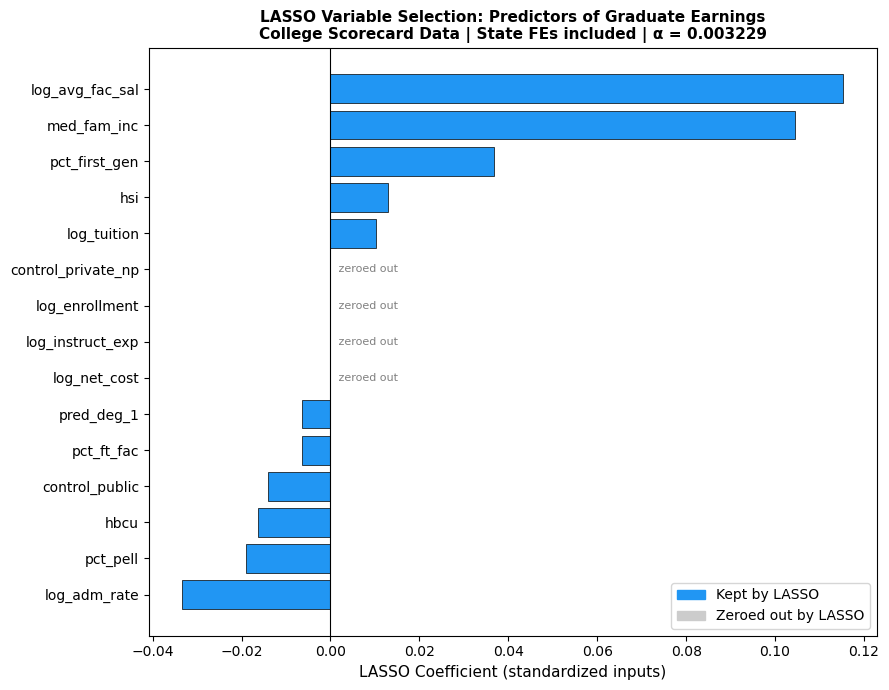

Saved to ../output/lasso_coefficients.png


In [20]:

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 12 substantive variables (no region/state dummies)
focus_vars = [
    'log_adm_rate', 'log_tuition', 'log_net_cost', 'log_instruct_exp',
    'log_avg_fac_sal', 'log_enrollment', 'pct_pell', 'pct_ft_fac',
    'med_fam_inc', 'pct_first_gen', 'hbcu', 'hsi',
    'control_private_np', 'control_public', 'pred_deg_1'
]

focus_df = coef_df[coef_df['variable'].isin(focus_vars)].copy()
focus_df = focus_df.sort_values('lasso_coef', ascending=True)

# Color: blue if kept, gray if zeroed out
colors = ['#2196F3' if v != 0 else '#CCCCCC' for v in focus_df['lasso_coef']]

fig, ax = plt.subplots(figsize=(9, 7))

bars = ax.barh(focus_df['variable'], focus_df['lasso_coef'],
               color=colors, edgecolor='black', linewidth=0.5)

ax.axvline(0, color='black', linewidth=0.8)

# Labels
ax.set_xlabel('LASSO Coefficient (standardized inputs)', fontsize=11)
ax.set_title('LASSO Variable Selection: Predictors of Graduate Earnings\n'
             'College Scorecard Data | State FEs included | α = 0.003229',
             fontsize=11, fontweight='bold')

# Legend
kept_patch   = mpatches.Patch(color='#2196F3', label='Kept by LASSO')
zeroed_patch = mpatches.Patch(color='#CCCCCC', label='Zeroed out by LASSO')
ax.legend(handles=[kept_patch, zeroed_patch], loc='lower right')

# Annotation for zeroed out vars
for _, row in focus_df.iterrows():
    if row['lasso_coef'] == 0:
        ax.text(0.001, list(focus_df['variable']).index(row['variable']),
                ' zeroed out', va='center', color='gray', fontsize=8)

plt.tight_layout()
plt.savefig('../output/lasso_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to ../output/lasso_coefficients.png")

COMPARISON between OLS and LASSO

In [21]:

ols_results = {
    'log_adm_rate':  {'coef': -0.064, 'pval': 0.012},  
    'sat_composite': {'coef': 0.000, 'pval': 0.000},
    'log_tuition':   {'coef': 0.092, 'pval': 0.027},
    'pct_pell':      {'coef': -0.332, 'pval': 0.058},
    'control_public':{'coef': 0.03, 'pval': 0.163},
}


lasso_coef_lookup = dict(zip(coef_df['variable'], coef_df['lasso_coef']))

print("="*72)
print(f"{'Variable':<22} {'OLS Coef':>10} {'OLS Sig':>8} {'LASSO Coef':>12} {'Agreement'}")
print("="*72)

for var, vals in ols_results.items():
    ols_c = vals['coef']
    ols_p = vals['pval']
    las_c = lasso_coef_lookup.get(var, 0.0)
    
   
    if ols_p is None:
        stars = "N/A"
    elif ols_p < 0.01:
        stars = "***"
    elif ols_p < 0.05:
        stars = "**"
    elif ols_p < 0.1:
        stars = "*"
    else:
        stars = ""

    
    if las_c == 0:
        agreement = "LASSO drops"
    elif ols_c is None:
        agreement = "?"
    elif (ols_c > 0) == (las_c > 0):
        agreement = "✓ agree"
    else:
        agreement = "✗ disagree"
    
    print(f"{var:<22} {str(ols_c):>10} {stars:>8} {las_c:>12.4f} {agreement}")

print("="*72)
print("\nNote: OLS coefficients are on original log scale.")
print("LASSO coefficients are on standardized scale.")
print("Comparison is directional only, not magnitude.")


print("\n--- Variables LASSO found that OLS didn't include ---")
lasso_only = ['log_avg_fac_sal', 'med_fam_inc', 'pct_first_gen', 
              'hbcu', 'hsi', 'log_net_cost', 'log_instruct_exp',
              'log_enrollment', 'pct_ft_fac']
for var in lasso_only:
    c = lasso_coef_lookup.get(var, 0.0)
    status = f"{c:.4f}  ✓ kept" if c != 0 else "0.0000  ✗ zeroed out"
    print(f"  {var:<22} {status}")

Variable                 OLS Coef  OLS Sig   LASSO Coef Agreement
log_adm_rate               -0.064       **      -0.0334 ✓ agree
sat_composite                 0.0      ***       0.0000 LASSO drops
log_tuition                 0.092       **       0.0103 ✓ agree
pct_pell                   -0.332        *      -0.0190 ✓ agree
control_public               0.03               -0.0141 ✗ disagree

Note: OLS coefficients are on original log scale.
LASSO coefficients are on standardized scale.
Comparison is directional only, not magnitude.

--- Variables LASSO found that OLS didn't include ---
  log_avg_fac_sal        0.1154  ✓ kept
  med_fam_inc            0.1044  ✓ kept
  pct_first_gen          0.0368  ✓ kept
  hbcu                   -0.0164  ✓ kept
  hsi                    0.0128  ✓ kept
  log_net_cost           0.0000  ✗ zeroed out
  log_instruct_exp       0.0000  ✗ zeroed out
  log_enrollment         0.0000  ✗ zeroed out
  pct_ft_fac             -0.0065  ✓ kept


MODEL PERFORMANCE 

/opt/anaconda3/envs/ec34/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


Metric                          Log FE OLS   OLS 83 vars         LASSO
N (estimation sample)                1,163         1,483         1,483
Features                           5 + FEs            83         83→40
R² in-sample                        0.6571        0.7200        0.7103
R² out-of-sample                    0.5974        0.6457        0.6552
CV R² (5-fold)                         N/A        0.2938        0.6420
RMSE in-sample                      0.1422        0.1419        0.1443
RMSE out-of-sample                  0.1536        0.1609        0.1587
Overfitting gap (R²)                0.0597        0.0743        0.0552
Note: Log FE OLS uses different sample (requires SAT scores).
OLS 83 vars and LASSO use identical sample and features.


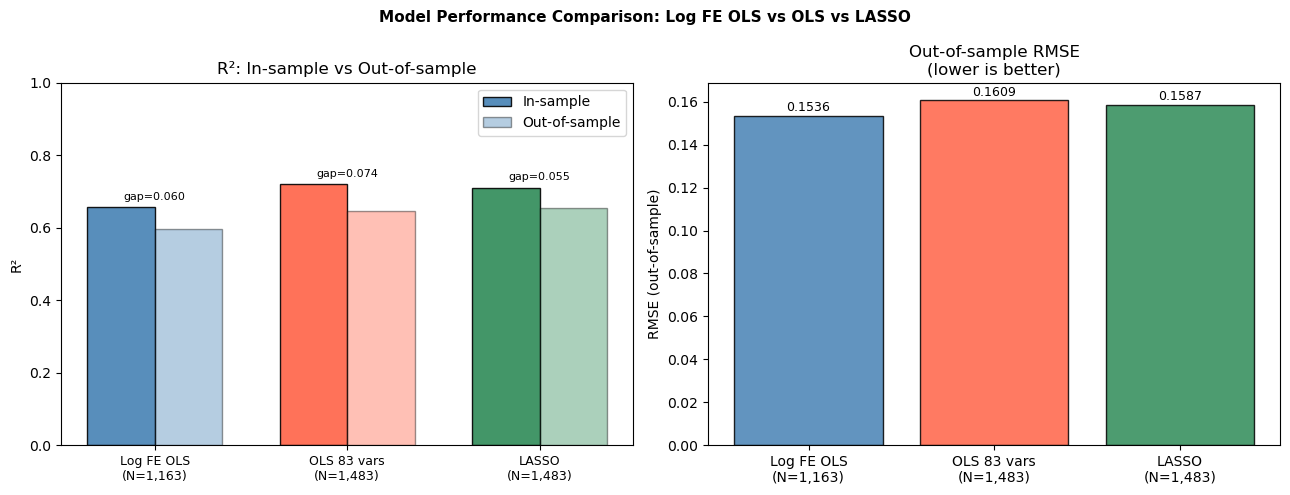

Saved to ../output/model_comparison.png


In [22]:
# Model comparison across all three models ─
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
import statsmodels.formula.api as smf

#  Log OLS FE
input_path = "../data/college_scorecard_clean.csv"
df_ols = pd.read_csv(input_path)

df_ols['log_earnings'] = np.log(df_ols['md_earn_10yr'])
df_ols['log_adm_rate'] = np.log(df_ols['adm_rate'])
df_ols['log_tuition']  = np.log(df_ols['tuition'])

formula = ("log_earnings ~ log_adm_rate + sat_composite + log_tuition "
           "+ C(control) + pct_pell + C(state)")

keep = ['log_earnings','log_adm_rate','sat_composite',
        'log_tuition','control','pct_pell','state']
df_ols = df_ols[keep].replace([np.inf,-np.inf], np.nan).dropna()

ols_fe = smf.ols(formula=formula, data=df_ols).fit(cov_type='HC3')

# In-sample R² and RMSE d
ols_fe_r2_in   = ols_fe.rsquared
ols_fe_rmse_in = np.sqrt(ols_fe.mse_resid)

# Out-of-sample
y_ols   = df_ols['log_earnings']
X_ols   = smf.ols(formula=formula, data=df_ols).fit().model.exog

np.random.seed(42)
idx      = np.random.permutation(len(y_ols))
cut      = int(0.8 * len(idx))
tr, te   = idx[:cut], idx[cut:]

ols_fit_tr = smf.ols(formula=formula,
                     data=df_ols.iloc[tr]).fit(cov_type='HC3')
y_hat_te   = ols_fit_tr.predict(df_ols.iloc[te])
y_te       = y_ols.iloc[te]

ols_fe_r2_out   = r2_score(y_te, y_hat_te)
ols_fe_rmse_out = np.sqrt(mean_squared_error(y_te, y_hat_te))

#  OLS with all variables
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_lasso, test_size=0.2, random_state=42
)

ols_full = LinearRegression().fit(X_train, y_train)

ols_full_r2_in    = r2_score(y_train, ols_full.predict(X_train))
ols_full_r2_out   = r2_score(y_test,  ols_full.predict(X_test))
ols_full_rmse_in  = np.sqrt(mean_squared_error(y_train, ols_full.predict(X_train)))
ols_full_rmse_out = np.sqrt(mean_squared_error(y_test,  ols_full.predict(X_test)))
ols_full_cv       = cross_val_score(
    LinearRegression(), X_scaled, y_lasso, cv=5, scoring='r2'
).mean()

# LASSO 
lasso_m = Lasso(alpha=lasso_cv.alpha_, max_iter=10000).fit(X_train, y_train)

lasso_r2_in    = r2_score(y_train, lasso_m.predict(X_train))
lasso_r2_out   = r2_score(y_test,  lasso_m.predict(X_test))
lasso_rmse_in  = np.sqrt(mean_squared_error(y_train, lasso_m.predict(X_train)))
lasso_rmse_out = np.sqrt(mean_squared_error(y_test,  lasso_m.predict(X_test)))
lasso_cv_r2    = cross_val_score(
    Lasso(alpha=lasso_cv.alpha_, max_iter=10000),
    X_scaled, y_lasso, cv=5, scoring='r2'
).mean()

# Comparison Table
print("="*72)
print(f"{'Metric':<28} {'Log FE OLS':>13} {'OLS 83 vars':>13} {'LASSO':>13}")
print("="*72)
print(f"{'N (estimation sample)':<28} {'1,163':>13} {'1,483':>13} {'1,483':>13}")
print(f"{'Features':<28} {'5 + FEs':>13} {'83':>13} {'83→40':>13}")
print(f"{'R² in-sample':<28} {ols_fe_r2_in:>13.4f} {ols_full_r2_in:>13.4f} {lasso_r2_in:>13.4f}")
print(f"{'R² out-of-sample':<28} {ols_fe_r2_out:>13.4f} {ols_full_r2_out:>13.4f} {lasso_r2_out:>13.4f}")
print(f"{'CV R² (5-fold)':<28} {'N/A':>13} {ols_full_cv:>13.4f} {lasso_cv_r2:>13.4f}")
print(f"{'RMSE in-sample':<28} {ols_fe_rmse_in:>13.4f} {ols_full_rmse_in:>13.4f} {lasso_rmse_in:>13.4f}")
print(f"{'RMSE out-of-sample':<28} {ols_fe_rmse_out:>13.4f} {ols_full_rmse_out:>13.4f} {lasso_rmse_out:>13.4f}")
print(f"{'Overfitting gap (R²)':<28} {ols_fe_r2_in-ols_fe_r2_out:>13.4f} {ols_full_r2_in-ols_full_r2_out:>13.4f} {lasso_r2_in-lasso_r2_out:>13.4f}")
print("="*72)
print("Note: Log FE OLS uses different sample (requires SAT scores).")
print("OLS 83 vars and LASSO use identical sample and features.")

#  Visualization 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

models    = ['Log FE OLS\n(N=1,163)', 'OLS 83 vars\n(N=1,483)', 'LASSO\n(N=1,483)']
r2_in     = [ols_fe_r2_in,   ols_full_r2_in,   lasso_r2_in]
r2_out    = [ols_fe_r2_out,  ols_full_r2_out,  lasso_r2_out]
rmse_out  = [ols_fe_rmse_out, ols_full_rmse_out, lasso_rmse_out]
colors    = ['steelblue', 'tomato', 'seagreen']

x = np.arange(len(models))
w = 0.35

# Left: R² in vs out 
axes[0].bar(x - w/2, r2_in,  w, label='In-sample',     color=colors, alpha=0.9, edgecolor='black')
axes[0].bar(x + w/2, r2_out, w, label='Out-of-sample', color=colors, alpha=0.4, edgecolor='black')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, fontsize=9)
axes[0].set_ylabel('R²')
axes[0].set_ylim(0, 1)
axes[0].set_title('R²: In-sample vs Out-of-sample')
axes[0].legend(['In-sample', 'Out-of-sample'])

# Overfitting gap annotations
for i, (ri, ro) in enumerate(zip(r2_in, r2_out)):
    axes[0].annotate(f'gap={ri-ro:.3f}',
                     xy=(x[i], max(ri, ro) + 0.02),
                     ha='center', fontsize=8, color='black')

# Right: RMSE out-of-sample 
bars = axes[1].bar(models, rmse_out, color=colors, edgecolor='black', alpha=0.85)
axes[1].set_ylabel('RMSE (out-of-sample)')
axes[1].set_title('Out-of-sample RMSE\n(lower is better)')
for bar, val in zip(bars, rmse_out):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.002,
                 f'{val:.4f}', ha='center', fontsize=9)

plt.suptitle('Model Performance Comparison: Log FE OLS vs OLS vs LASSO',
             fontweight='bold', fontsize=11)
plt.tight_layout()
plt.savefig('../output/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to ../output/model_comparison.png")

In [23]:
#prediction error
rmse_log = 0.1587
avg_earnings = np.exp(y_lasso.mean())

print(f"Mean log earnings:          {y_lasso.mean():.4f}")
print(f"Mean earnings (level):      ${avg_earnings:,.0f}")
print(f"RMSE in log points:         {rmse_log:.4f}")
print(f"Approx % prediction error:  {rmse_log*100:.1f}%")
print(f"In dollar terms (~):        ${avg_earnings * rmse_log:,.0f}")

Mean log earnings:          10.9115
Mean earnings (level):      $54,803
RMSE in log points:         0.1587
Approx % prediction error:  15.9%
In dollar terms (~):        $8,697


Random Forrest Robustness Check

RF R² in-sample:     0.8857
RF R² out-of-sample: 0.7894
RF RMSE (test):      0.1240
RF overfitting gap:  0.0963


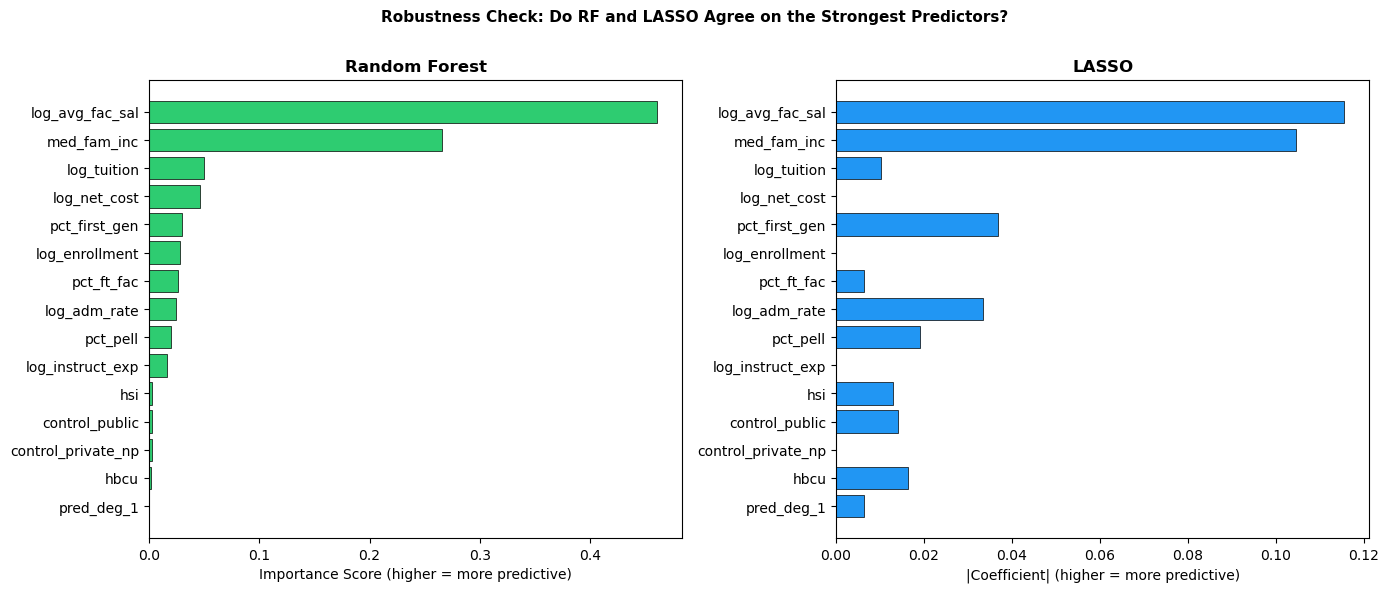

Saved to ../output/rf_vs_lasso.png

Variable                   RF Rank LASSO Rank
log_avg_fac_sal                  1          1
med_fam_inc                      2          2
log_tuition                      3          9
log_net_cost                     4         13
pct_first_gen                    5          3
log_enrollment                   6         13
pct_ft_fac                       7         10
log_adm_rate                     8          4
pct_pell                         9          5
log_instruct_exp                10         13
hsi                             11          8
control_public                  12          7
control_private_np              13         13
hbcu                            14          6
pred_deg_1                      15         11


In [24]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_lasso, test_size=0.2, random_state=42
)

rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

rf_r2_in  = rf.score(X_train, y_train)
rf_r2_out = rf.score(X_test,  y_test)
rf_rmse   = np.sqrt(mean_squared_error(y_test, rf.predict(X_test)))

print(f"RF R² in-sample:     {rf_r2_in:.4f}")
print(f"RF R² out-of-sample: {rf_r2_out:.4f}")
print(f"RF RMSE (test):      {rf_rmse:.4f}")
print(f"RF overfitting gap:  {rf_r2_in - rf_r2_out:.4f}")

focus_vars = [
    'log_adm_rate', 'log_tuition', 'log_net_cost', 'log_instruct_exp',
    'log_avg_fac_sal', 'log_enrollment', 'pct_pell', 'pct_ft_fac',
    'med_fam_inc', 'pct_first_gen', 'hbcu', 'hsi',
    'control_private_np', 'control_public', 'pred_deg_1'
]

focus_idx   = [list(X_lasso.columns).index(v) for v in focus_vars if v in X_lasso.columns]
focus_names = [X_lasso.columns[i] for i in focus_idx]

rf_importance = pd.DataFrame({
    'variable':     focus_names,
    'rf_importance': rf.feature_importances_[focus_idx]
}).sort_values('rf_importance', ascending=True)

lasso_abs = pd.DataFrame({
    'variable':  coef_df['variable'],
    'lasso_abs': coef_df['lasso_coef'].abs()
})
lasso_abs = lasso_abs[lasso_abs['variable'].isin(focus_vars)]

compare = rf_importance.merge(lasso_abs, on='variable')
compare = compare.sort_values('rf_importance', ascending=True)


#Visualization 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors_rf = ['#2ecc71' for v in compare['rf_importance']]
axes[0].barh(compare['variable'], compare['rf_importance'],
             color=colors_rf, edgecolor='black', linewidth=0.5)
axes[0].set_title('Random Forest', fontweight='bold')
axes[0].set_xlabel('Importance Score (higher = more predictive)')

colors_lasso = ['#2196F3' if v != 0 else '#cccccc' for v in compare['lasso_abs']]
axes[1].barh(compare['variable'], compare['lasso_abs'],
             color=colors_lasso, edgecolor='black', linewidth=0.5)
axes[1].set_title('LASSO', fontweight='bold')
axes[1].set_xlabel('|Coefficient| (higher = more predictive)')

plt.suptitle('Robustness Check: Do RF and LASSO Agree on the Strongest Predictors?\n',
             fontweight='bold', fontsize=11)
plt.tight_layout()
plt.savefig('../output/rf_vs_lasso.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to ../output/rf_vs_lasso.png")

compare_ranked = compare.copy()
compare_ranked['rf_rank']    = compare_ranked['rf_importance'].rank(ascending=False).astype(int)
compare_ranked['lasso_rank'] = compare_ranked['lasso_abs'].rank(ascending=False).astype(int)
compare_ranked = compare_ranked.sort_values('rf_rank')

print("\n" + "="*55)
print(f"{'Variable':<25} {'RF Rank':>8} {'LASSO Rank':>10}")
print("="*55)
for _, row in compare_ranked.iterrows():
    print(f"{row['variable']:<25} {row['rf_rank']:>8} {row['lasso_rank']:>10}")
print("="*55)